# Capítulo 1 (SEMMA: Sample y Explore)

## Contexto del dataset

El dataset cargado actualmente corresponde a información catastral y contiene variables relacionadas con edificaciones. Para mantener coherencia metodológica y facilitar el análisis descriptivo del proyecto, se trabajará únicamente con las siguientes variables:

- `DEPARTAMENTO`
- `Numero_Pisos`

Posteriormente se integrará el dataset de estratos socioeconómicos.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1.2 Fuentes de información y selección del conjunto de datos

In [3]:
df = pd.read_csv(
    r'C:\Users\STIVEN\OneDrive\universidad\diplomado\Final\data\raw\dataset-CATASTRO-PUBLICO.csv',
    encoding='latin1',
    sep=';'
)

In [4]:
df.head()

,OBJECTID,Codigo,Terreno_Codigo,Tipo_Construccion,Tipo_Dominio,Numero_Pisos,Numero_Sotanos,Numero_Mezanines,Numero_Semisotanos,Etiqueta,Identificador,Codigo_Edificacion,Codigo_Anterior,GLOBALID,DEPARTAMENTO,Shape__Area,Shape__Length
0,1,157640100000000250010000000000,157640100000000250010000000000,CONVENCIONAL,PRIVADO,2,0,0,0,0,A-B,1.0,15764010000250010000,674a4ff4-a739-45bf-90aa-6a3b61325d1e,CAUCA,"28,21337891","22,14964995"
1,2,157640100000000250026000000000,157640100000000250026000000000,CONVENCIONAL,PRIVADO,1,0,0,0,0,A,1.0,15764010000250026000,3699a453-0d30-4714-bdd9-d64cd9af9d25,Antioquia,"148,7758789","52,84152652"
2,3,157640100000000250011000000000,NaN,CONVENCIONAL,PRIVADO,1,0,0,0,0,A,1.0,15764010000250011000,c77418cb-e59e-4efd-8b62-f923edb2128f,ANTIOQUIA,"108,3251953","43,20766152"
3,4,157640100000000250011000000000,NaN,CONVENCIONAL,PRIVADO,1,0,0,0,0,B,1.0,15764010000250011000,baec0ce2-ead0-4a0f-a6d5-50b30a2293cf,Antioquia,"63,10009766","51,7578177"
4,5,157640100000000250023000000000,157640100000000250023000000000,CONVENCIONAL,PRIVADO,3,0,0,0,0,A-B,1.0,15764010000250023000,aa330797-5886-45c0-9cc9-2195642ba157,ANTIOQUIA,"54,9296875","29,6990689"


In [5]:
print(df.shape)

(50000, 17)


# 1.3 Identificación de variables relevantes

Se identificaron las variables necesarias para el análisis descriptivo territorial:

- DEPARTAMENTO
- Numero_Pisos

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 17 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   OBJECTID            50000 non-null  int64  
 1   Codigo              50000 non-null  object 
 2   Terreno_Codigo      49425 non-null  object 
 3   Tipo_Construccion   50000 non-null  object 
 4   Tipo_Dominio        48906 non-null  object 
 5   Numero_Pisos        50000 non-null  int64  
 6   Numero_Sotanos      50000 non-null  int64  
 7   Numero_Mezanines    50000 non-null  int64  
 8   Numero_Semisotanos  50000 non-null  int64  
 9   Etiqueta            608 non-null    object 
 10  Identificador       50000 non-null  object 
 11  Codigo_Edificacion  48735 non-null  float64
 12  Codigo_Anterior     49589 non-null  object 
 13  GLOBALID            50000 non-null  object 
 14  DEPARTAMENTO        50000 non-null  object 
 15  Shape__Area         50000 non-null  object 
 16  Shap

In [7]:
df.describe()

,OBJECTID,Numero_Pisos,Numero_Sotanos,Numero_Mezanines,Numero_Semisotanos,Codigo_Edificacion
count,50000.000000,50000.000000,50000.0,50000.0,50000.0,48735.000000
mean,25000.500000,1.020080,0.0,0.0,0.0,1.820150
std,14433.901067,0.173544,0.0,0.0,0.0,11.890565
min,1.000000,0.000000,0.0,0.0,0.0,1.000000
25%,12500.750000,1.000000,0.0,0.0,0.0,1.000000
50%,25000.500000,1.000000,0.0,0.0,0.0,1.000000
75%,37500.250000,1.000000,0.0,0.0,0.0,1.000000
max,50000.000000,5.000000,0.0,0.0,0.0,469.000000


In [8]:
df.columns

Index(['OBJECTID', 'Codigo', 'Terreno_Codigo', 'Tipo_Construccion',
       'Tipo_Dominio', 'Numero_Pisos', 'Numero_Sotanos', 'Numero_Mezanines',
       'Numero_Semisotanos', 'Etiqueta', 'Identificador', 'Codigo_Edificacion',
       'Codigo_Anterior', 'GLOBALID', 'DEPARTAMENTO', 'Shape__Area',
       'Shape__Length'],
      dtype='object')

In [9]:
df_base = df[
    [
        'DEPARTAMENTO',
        'Numero_Pisos'
    ]
].copy()

In [10]:
df_base.columns = [
    'departamento',
    'numero_pisos'
]

In [11]:
df_base.head()

,departamento,numero_pisos
0,CAUCA,2
1,Antioquia,1
2,ANTIOQUIA,1
3,Antioquia,1
4,ANTIOQUIA,3


In [12]:
df_base.isnull().sum()

departamento    0
numero_pisos    0
dtype: int64

In [13]:
df_base['departamento'].unique()

array(['CAUCA', 'Antioquia', 'ANTIOQUIA', 'Cauca', 'Ant ioquia',
       ' cauca ', 'Cundinamarca', 'cundinamarca', 'cauca', 'antioquia',
       'CAU ca', 'cundinamarc', 'CUNDINAMARCA', 'antioquía'], dtype=object)

In [14]:
df_base['numero_pisos'].value_counts()

numero_pisos
1    48862
2      920
0      124
3       77
4       14
5        3
Name: count, dtype: int64

# 1.4 Exploración inicial de la distribución de edificaciones

In [15]:
df_base['numero_pisos'].value_counts()

numero_pisos
1    48862
2      920
0      124
3       77
4       14
5        3
Name: count, dtype: int64

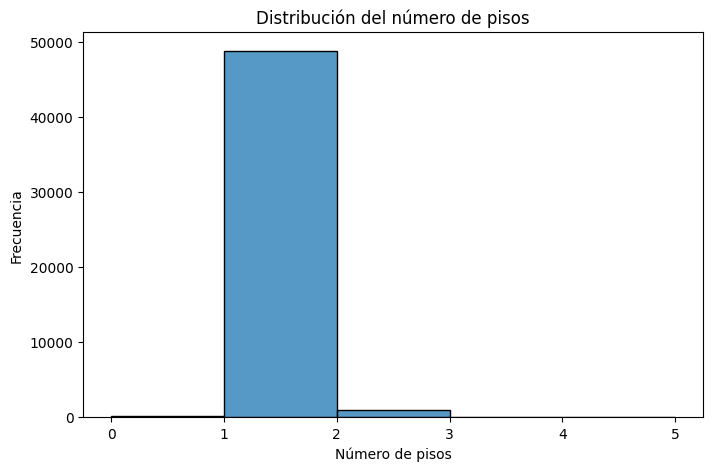

In [16]:
plt.figure(figsize=(8,5))

sns.histplot(
    data=df_base,
    x='numero_pisos',
    bins=5
)

plt.title('Distribución del número de pisos')
plt.xlabel('Número de pisos')
plt.ylabel('Frecuencia')

plt.show()

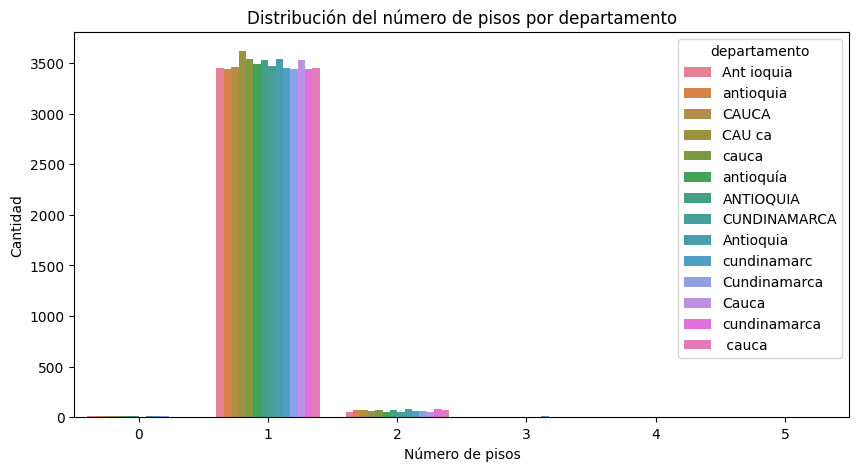

In [17]:
plt.figure(figsize=(10,5))

sns.countplot(
    data=df_base,
    x='numero_pisos',
    hue='departamento'
)

plt.title('Distribución del número de pisos por departamento')
plt.xlabel('Número de pisos')
plt.ylabel('Cantidad')

plt.show()

# 1.5 Revisión de calidad de datos

In [18]:
df_base.isnull().sum()

departamento    0
numero_pisos    0
dtype: int64

In [19]:
df_base.duplicated().sum()

np.int64(49932)

In [20]:
df_base['departamento'].unique()

array(['CAUCA', 'Antioquia', 'ANTIOQUIA', 'Cauca', 'Ant ioquia',
       ' cauca ', 'Cundinamarca', 'cundinamarca', 'cauca', 'antioquia',
       'CAU ca', 'cundinamarc', 'CUNDINAMARCA', 'antioquía'], dtype=object)

# Hallazgos preliminares

- El dataset contiene 50.000 registros relacionados con edificaciones.
- La variable `numero_pisos` presenta valores entre 0 y 5 pisos.
- La mayoría de las edificaciones presentan un solo piso.
- No se identificaron valores nulos en las variables seleccionadas.
- La variable `departamento` permitirá realizar comparaciones territoriales.
- El dataset será complementado posteriormente con información de estrato socioeconómico.